# Group-level apples-to-apples comparison (Rutherford 2023 eLife design)

`5_deseq2_group_comparison.ipynb` compared normative_union (K=1 union of per-patient BH-significant
genes across a whole cohort) against DESeq2's group test -- different statistical units (min-p
aggregation vs one p-value per gene), which confounds the comparison (see
`Benchmark/FDR_THRESHOLD_RATIONALE.md`).

This notebook applies DESeq2's OWN statistical design -- one p-value per gene from a single
group-level test, BH-FDR, hypergeometric-vs-OT-reference -- to normative Z-scores instead of raw
counts, isolating whether deviation scores carry more disease signal than raw counts at the SAME
statistical unit:

- **Gene level**: DESeq2 Wald stat vs normative group Stouffer's Z (`db_hit_compare.group_level_z_test`)
- **Pathway level**: real preranked GSEA (Subramanian 2005) on each ranking, replacing the ad hoc
  mean-Z+permutation-null scorer used elsewhere (`db_hit_compare.group_level_pathway_gsea`)

This does NOT replace `5_deseq2_group_comparison.ipynb`'s normative_union results -- that notebook
answers "does per-patient individual-level detection find real signal"; this one answers "does the
deviation-score feature itself carry more group-separable signal than the raw count feature."

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

BENCH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark'

In [2]:
DESEQ2_DESIGNS = ['no_covariate', 'covariate', 'ruvg_k2']

# phenotype -> contributing study/author labels (same min_n=3 filter as dc.stouffer_group_z,
# e.g. Liver Cancer pools Chen et al. + Roskams-Hieter B et al.; Block et al. dropped, n=2)
sm = pd.read_csv(dc.ZDIR / 'sample_meta.csv')
sm['study'] = sm['batch'].str.replace(r'_Batch_\d+$', '', regex=True)
study_counts = sm[sm.ood_keep].groupby(['phenotype', 'study']).size()
pheno_studies = {}
for (pheno, study), n in study_counts[study_counts >= 3].items():
    pheno_studies.setdefault(pheno, []).append(study.replace(' et al.', ''))


def pheno_label(p):
    studies = sorted(pheno_studies.get(p, []))
    return f"{p} ({', '.join(studies)})" if studies else p

## 1. Gene level -- Stouffer's Z vs DESeq2 Wald stat

In [3]:
GENE_Z_PATH = BENCH / 'group_level_z_test_multidesign.csv'
if GENE_Z_PATH.exists():
    gene_z = pd.read_csv(GENE_Z_PATH)
else:
    parts = [dc.group_level_z_test(deseq2_design=d) for d in DESEQ2_DESIGNS]
    # normative_group_z rows are identical across calls (design only affects the deseq2_* rows) -- keep once
    gene_z = pd.concat([parts[0]] + [p[p.method != 'normative_group_z'] for p in parts[1:]], ignore_index=True)
    gene_z.to_csv(GENE_Z_PATH, index=False)

print('significant phenotypes (hypergeometric padj<0.05) by method x q:')
display(gene_z.groupby(['method', 'q'])['sig_fdr05'].agg(n_sig='sum', n_total='size'))

significant phenotypes (hypergeometric padj<0.05) by method x q:


n_sig  n_total
method              q                   
deseq2_covariate    0.05      4       13
                    0.10      5       13
                    0.15      5       13
                    0.20      4       13
deseq2_no_covariate 0.05      9       13
                    0.10      9       13
                    0.15      7       13
                    0.20      9       13
deseq2_ruvg_k2      0.05      5       13
                    0.10      5       13
                    0.15      6       13
                    0.20      7       13
normative_group_z   0.05      7       14
                    0.10      8       14
                    0.15      8       14
                    0.20      7       14

In [4]:
q05 = gene_z[gene_z.q == 0.05].sort_values(['phenotype', 'method']).reset_index(drop=True)
display(q05[['phenotype', 'method', 'n_sig', 'overlap', 'ref_size', 'pval', 'padj', 'sig_fdr05']])

,phenotype,method,n_sig,overlap,ref_size,pval,padj,sig_fdr05
0,Colorectal Cancer,deseq2_covariate,49,2,300,1.690814e-01,2.932408e-01,False
1,Colorectal Cancer,deseq2_no_covariate,10041,192,300,1.559889e-06,5.615602e-06,True
2,Colorectal Cancer,deseq2_ruvg_k2,88,1,300,7.388209e-01,8.128143e-01,False
3,Colorectal Cancer,normative_group_z,6407,95,300,6.097257e-01,6.719426e-01,False
4,Esophagus Cancer,deseq2_covariate,24,1,300,3.061880e-01,4.657508e-01,False
5,Esophagus Cancer,deseq2_no_covariate,432,12,300,3.201287e-02,5.160283e-02,False
6,Esophagus Cancer,deseq2_ruvg_k2,136,2,300,6.116283e-01,7.258886e-01,False
7,Esophagus Cancer,normative_group_z,3535,52,300,6.083093e-01,6.719426e-01,False
8,HIV,deseq2_covariate,39,3,299,2.071499e-02,4.863520e-02,True
9,HIV,deseq2_no_covariate,52,4,299,7.734114e-03,1.465411e-02,True


In [5]:
# per-(phenotype, study) breakdown at q=0.05 -- phenotypes pooling multiple cohorts (e.g. Liver
# Cancer = Chen et al. + Roskams-Hieter B et al.) get one row per study instead of one combined bar.
import pickle
from scipy.stats import hypergeom, norm
from MixedEffectsModeling.core.calibration import bh_fdr_reject

ref = dc.load_reference()
sym_of = dc.ensg_to_symbol()
gene_names = pickle.load(open(dc.ZDIR / 'gene_names.pkl', 'rb'))
sym_arr = sym_of.reindex(gene_names).values
N_genes = len(gene_names)
group_z = dc.stouffer_group_z()  # {(pheno, study): gz}, min_n=3 already applied

rows = []
for (pheno, study), gz in group_z.items():
    dref = ref.get(pheno, set())
    if not dref:
        continue
    finite = np.isfinite(gz)
    p = np.full(len(gz), np.nan)
    p[finite] = 2 * norm.sf(np.abs(gz[finite]))
    reject = np.zeros(len(gz), dtype=bool)
    reject[finite] = bh_fdr_reject(p[finite], q=0.05)
    sig = {s for s in sym_arr[reject] if pd.notna(s)}
    K, n, x = len(dref), len(sig), len(sig & dref)
    pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
    rows.append(dict(phenotype=pheno, study=study, method='normative_group_z', n_sig=n, n_db=x, ref_size=K, pval=pval))

sym_of_v = sym_of.copy()
sym_of_v.index = sym_of_v.index.str.split('.').str[0]
for design in DESEQ2_DESIGNS:
    for (study, pheno), res in dc.deseq2_study_results(design).items():
        dref = ref.get(pheno, set())
        if not dref:
            continue
        sig = set(sym_of_v.reindex(res.index[res['padj'] < 0.05]).dropna())
        K, n, x = len(dref), len(sig), len(sig & dref)
        pval = hypergeom.sf(x - 1, N_genes, K, n) if n > 0 else np.nan
        rows.append(dict(phenotype=pheno, study=study, method=f'deseq2_{design}', n_sig=n, n_db=x, ref_size=K, pval=pval))

gene_z_study = pd.DataFrame(rows)
gene_z_study['has_ot_ref'] = gene_z_study['ref_size'] > 0
display(gene_z_study[gene_z_study.phenotype == 'Liver Cancer'])

,phenotype,study,method,n_sig,n_db,ref_size,pval,has_ot_ref
4,Liver Cancer,Chen et al.,normative_group_z,12973,199,300,0.381454,True
5,Liver Cancer,Roskams-Hieter B et al.,normative_group_z,15097,245,300,0.010984,True
20,Liver Cancer,Chen et al.,deseq2_no_covariate,1269,34,300,0.000852,True
27,Liver Cancer,Roskams-Hieter B et al.,deseq2_no_covariate,15,0,300,1.000000,True
34,Liver Cancer,Chen et al.,deseq2_covariate,16,1,300,0.216241,True
41,Liver Cancer,Roskams-Hieter B et al.,deseq2_covariate,28,2,300,0.066476,True
48,Liver Cancer,Chen et al.,deseq2_ruvg_k2,277,7,300,0.127758,True
55,Liver Cancer,Roskams-Hieter B et al.,deseq2_ruvg_k2,172,4,300,0.262590,True


## 2. Pathway level -- preranked GSEA on the same two rankings

`gp.prerank` (Subramanian 2005 weighted running-sum + gene-label permutation null), same
KEGG_2021_Human + Reactome_2022 housekeeping-filtered library as `4_gene_enrichment.ipynb`.
q<0.05 = confirmatory, q<0.25 = GSEA's own discovery-tier convention
(`Benchmark/FDR_THRESHOLD_RATIONALE.md`).

In [6]:
PATH_GSEA_PATH = BENCH / 'pathway_gsea_db_hit_rates_multidesign.csv'
if PATH_GSEA_PATH.exists():
    path_gsea = pd.read_csv(PATH_GSEA_PATH)
else:
    parts = [dc.group_level_pathway_gsea(save=False, deseq2_design=d) for d in DESEQ2_DESIGNS]
    # normative_group_gsea* rows are identical across calls -- keep once
    path_gsea = pd.concat(
        [parts[0]] + [p[~p.method.str.startswith('normative_group_gsea')] for p in parts[1:]],
        ignore_index=True)
    path_gsea.to_csv(PATH_GSEA_PATH, index=False)

display(path_gsea[path_gsea.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_cov_gsea,61,25,0.410,True
1,Colorectal Cancer,deseq2_cov_gsea_q025,252,110,0.437,True
2,Colorectal Cancer,deseq2_no_cov_gsea,31,13,0.419,True
3,Colorectal Cancer,deseq2_no_cov_gsea_q025,250,80,0.320,True
4,Colorectal Cancer,deseq2_ruvg_k2_gsea,93,20,0.215,True
...,...,...,...,...,...,...
101,Tuberculosis,deseq2_no_cov_gsea_q025,521,173,0.332,True
102,Tuberculosis,deseq2_ruvg_k2_gsea,172,90,0.523,True
103,Tuberculosis,deseq2_ruvg_k2_gsea_q025,398,165,0.415,True
104,Tuberculosis,normative_group_gsea,713,275,0.386,True


In [7]:
# per-(phenotype, study) breakdown, mirroring the gene-level cell above -- reuses cached GSEA
# results (gsea_cache/) computed by path-compute, so this is fast (no GSEA rerun).
from MixedEffectsModeling.core.pathway_convergence import collapse_to_symbols, load_pathway_library, load_symbol_vocab

universe_syms, sym2idx, col2sym = load_symbol_vocab(None)
terms, M = load_pathway_library()
N_syms = len(universe_syms)
ref_path = {ph: dc.reference_pathways(syms, sym2idx, terms, M) for ph, syms in ref.items()}

rows = []
for (pheno, study), gz in group_z.items():
    if not ref_path.get(pheno):
        continue
    Zu, Fm = collapse_to_symbols(gz[None, :], col2sym, N_syms)
    rnk = np.where(Fm[0] > 0, Zu[0], np.nan)
    res2d = dc._cached_gsea(f"normative__{pheno}__{study}", rnk, terms, M, universe_syms)
    sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
    d = dc.db_hit_row(pheno, 'normative_group_gsea', sig, ref_path)
    d['study'] = study
    rows.append(d)

deseq2_summary = pd.read_csv(dc.DESEQ_DIR / 'summary.csv')
for design in DESEQ2_DESIGNS:
    method = f"{dc.DESIGN_LABELS[design]}_gsea"
    for _, r in deseq2_summary[deseq2_summary.design == design].iterrows():
        pheno, study = r.phenotype, r.study
        if not ref_path.get(pheno):
            continue
        path = dc.DESEQ_DIR / design / f"{dc.deseq2_tag(study, pheno)}.csv"
        if not path.exists():
            continue
        res = pd.read_csv(path, index_col=0)
        res.index = res.index.str.split('.').str[0]
        stat = res['stat'].dropna()
        syms = sym_of.reindex(stat.index)
        rnk_df = pd.Series(stat.values, index=syms.values)
        rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
        res2d = dc._cached_gsea(f"{design}__{dc.deseq2_tag(study, pheno)}", rnk_df.values, terms, M, universe_syms)
        sig = set(res2d.loc[res2d['FDR q-val'] < 0.05, 'Term'])
        d = dc.db_hit_row(pheno, method, sig, ref_path)
        d['study'] = study
        rows.append(d)

path_gsea_study = pd.DataFrame(rows)
display(path_gsea_study[path_gsea_study.phenotype == 'Liver Cancer'])

/tmp/ipykernel_413168/1698848626.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
/tmp/ipykernel_413168/1698848626.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rnk_df = rnk_df[pd.notna(rnk_df.index)].groupby(level=0).mean().reindex(universe_syms)
/tmp/ipykernel_413168/1698848626.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref,study
4,Liver Cancer,normative_group_gsea,513,162,0.316,True,Chen et al.
5,Liver Cancer,normative_group_gsea,17,6,0.353,True,Roskams-Hieter B et al.
20,Liver Cancer,deseq2_no_cov_gsea,57,11,0.193,True,Chen et al.
27,Liver Cancer,deseq2_no_cov_gsea,131,51,0.389,True,Roskams-Hieter B et al.
34,Liver Cancer,deseq2_cov_gsea,21,1,0.048,True,Chen et al.
41,Liver Cancer,deseq2_cov_gsea,32,1,0.031,True,Roskams-Hieter B et al.
48,Liver Cancer,deseq2_ruvg_k2_gsea,43,4,0.093,True,Chen et al.
55,Liver Cancer,deseq2_ruvg_k2_gsea,153,67,0.438,True,Roskams-Hieter B et al.


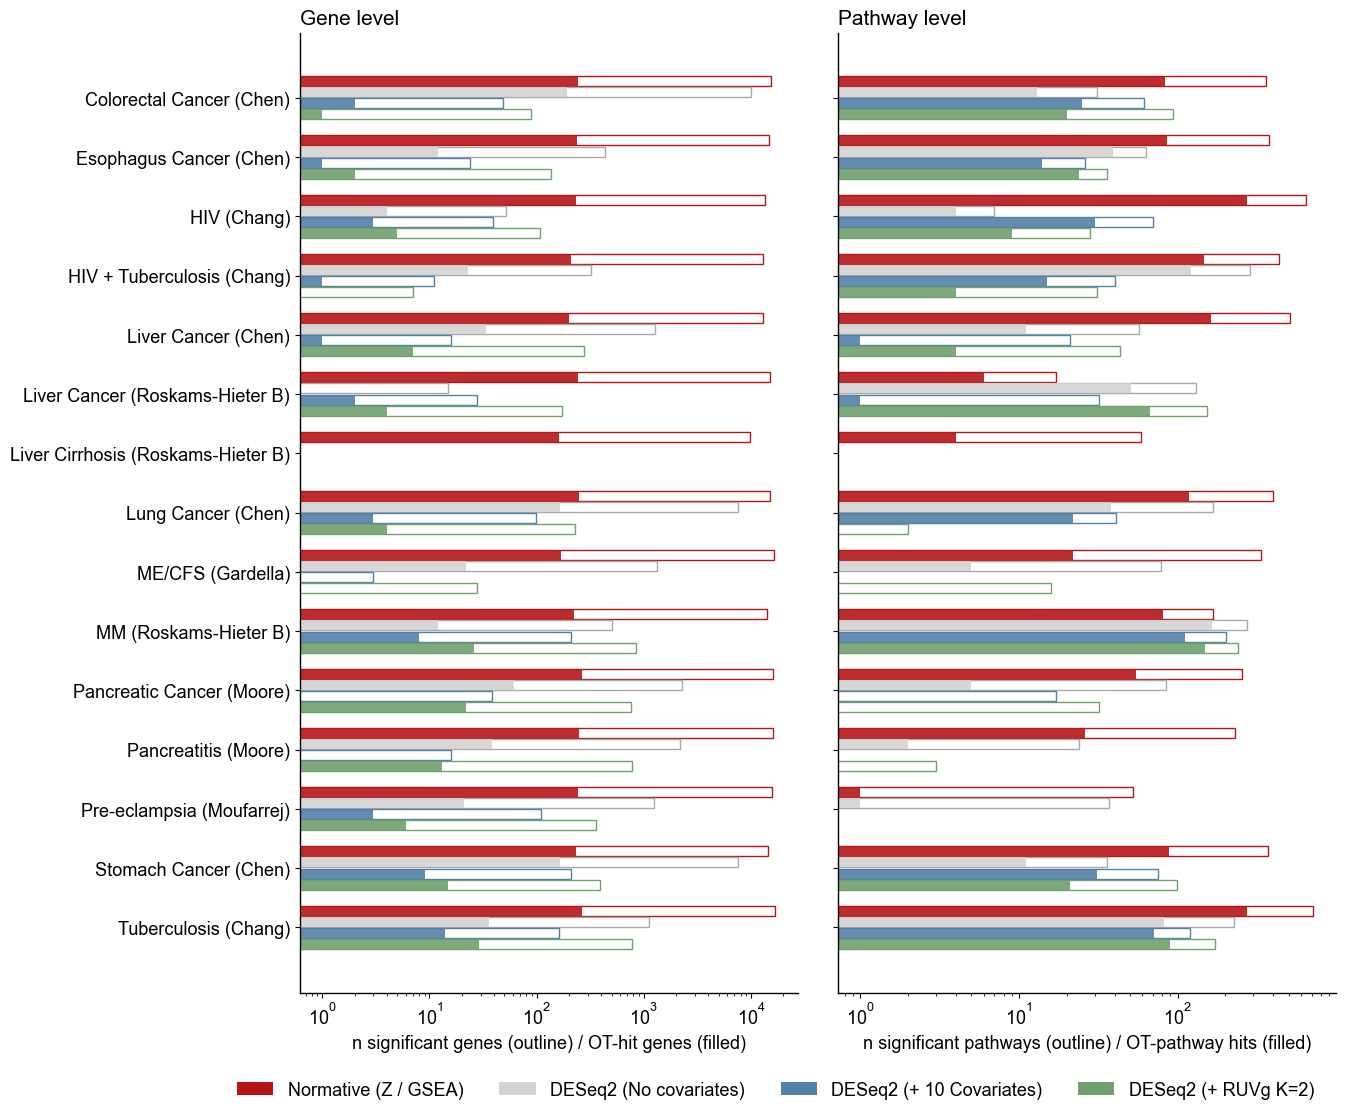

In [8]:
# combined gene + pathway view, shared y-axis (phenotype/study rows)
sub_g = gene_z_study[gene_z_study.has_ot_ref].copy()
sub_g['row_label'] = sub_g.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)
sub_p = path_gsea_study[path_gsea_study.has_ot_ref].copy()
sub_p['row_label'] = sub_p.apply(lambda r: f"{r.phenotype} ({r.study.replace(' et al.', '')})", axis=1)

rows_ = sorted(set(sub_g.row_label) | set(sub_p.row_label), reverse=True)
y = np.arange(len(rows_))

gene_methods = ['normative_group_z', 'deseq2_no_covariate', 'deseq2_covariate', 'deseq2_ruvg_k2']
path_methods = ['normative_group_gsea', 'deseq2_no_cov_gsea', 'deseq2_cov_gsea', 'deseq2_ruvg_k2_gsea']
colors = [
    "#B61518",  # Normative: Vivid Red (Highest salience for proposed method)
    '#D3D3D3',  # No covariates: Light Gray (Receded, low reliability)
    "#5280A6",  # + 10 Covariates: Steel Blue (Standard strong baseline 1)
    "#70A06E"   # + RUVg K=2: Green (Standard strong baseline 2, distinct from Blue)
]
level_labels = ['Normative (Z / GSEA)', 'DESeq2 (No covariates)', 'DESeq2 (+ 10 Covariates)', 'DESeq2 (+ RUVg K=2)']

n_m = 4
width = 0.75 / n_m


def plot_level(ax, sub, methods, xlabel, title):
    for j, (m, c) in enumerate(zip(methods, colors)):
        offset = ((n_m - 1) / 2 - j) * width
        n_sig_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_sig'].sum() for r in rows_]
        n_db_v = [sub[(sub.row_label == r) & (sub.method == m)]['n_db'].sum() for r in rows_]
        edge_color = '#A9A9A9' if j == 1 else c
        ax.barh(y + offset, n_sig_v, height=width * 0.9, facecolor='none', edgecolor=edge_color, linewidth=1)
        ax.barh(y + offset, n_db_v, height=width * 0.9, facecolor=c, edgecolor='none', alpha=0.9)
    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)


fig, (axG, axP) = plt.subplots(1, 2, figsize=(14, 12), sharey=True)
plot_level(axG, sub_g, gene_methods, 'n significant genes (outline) / OT-hit genes (filled)', 'Gene level')
plot_level(axP, sub_p, path_methods, 'n significant pathways (outline) / OT-pathway hits (filled)', 'Pathway level')
axG.set_yticks(y)
axG.set_yticklabels(rows_)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in colors]
fig.legend(handles, level_labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=4, frameon=False)

plt.subplots_adjust(left=0.16, bottom=0.08, wspace=0.08)
fig.savefig(BENCH / 'Figures' / 'group_level_comparison_combined.png', bbox_inches='tight', dpi=300)

### Caveat: Stouffer's Z can dilute heterogeneous/sparse disease signal

The gene- and pathway-level wins above use `Σz/√n` (Stouffer 1949) to combine per-patient Z into
one group statistic -- valid when patients deviate in a roughly consistent direction, but this
combination rule is the *dense/uniform-shift* case of the p-value/Z combination family. If only a
subset of patients truly deviate on a given gene (clinically realistic heterogeneity) the large
per-patient z's get averaged down by the many near-null ones, since `n` counts every patient
whether they deviate or not (Zhang, Tong, Landers & Wu 2020, *Ann. Appl. Stat.*,
doi:10.1214/19-aoas1302, motivate truncated/weighted alternatives to plain Fisher/Stouffer for
exactly this rare-strong-signal regime).

That means this notebook's group-level Stouffer test is likely a *conservative* read on normative
modeling's advantage -- it deliberately gives up the per-patient heterogeneity handling that
`5_deseq2_group_comparison.ipynb`'s normative_union (per-patient recurrence, no averaging across
patients) was built to exploit, in exchange for being apples-to-apples with DESeq2's single
group-level coefficient. The two notebooks answer different questions; neither result generalizes
to the other's estimand.

Design provenance: the head-to-head "normative-model feature vs raw feature, same statistical
unit" comparison itself follows Rutherford et al. 2023 (*eLife*, doi:10.7554/elife.85082,
"Evidence for embracing normative modeling"), building on Marquand et al. 2016 (*Biol. Psychiatry*,
doi:10.1016/j.biopsych.2015.12.023) -- both normative-modeling papers, not the RNA-seq
meta-analysis literature. The Stouffer-combination mechanics (why combining per-patient Z beats a
single raw-count regression at small per-cohort n) are separately supported by the microarray
meta-analysis literature (Tseng, Ghosh & Feingold 2012, *NAR*, doi:10.1093/nar/gkr1265; Marot et
al. 2009, *Bioinformatics*, doi:10.1093/bioinformatics/btp444) -- a parallel justification, not the
source of the comparison design.